# **Controle de Velocidade de um Carro 🚗**

*   **Entradas:**

    -   Distância do carro à frente (Perto, Médio, Longe)
    -   Velocidade atual (Baixa, Média, Alta)

*   **Saída:**

    -   Aceleração (Frear, Manter, Acelerar)

**Ideia:**
-   Simula um controle de cruzeiro adaptativo simples.

# **Variáveis linguísticas**
**Entradas**

*   Distância (0 a 100 m) - Triangular
    -   Perto (0, 0, 50)
    -   Média (25, 50, 75)
    -   Longe (50, 100, 100)

*   Velocidade (0 a 120 km/h) - Triangular
    -   Baixa → (0, 0, 60)
    -   Média → (40, 70, 100)
    -   Alta → (80, 120, 120)

**Saída**
*   Ação (-100 a 100)
    - Frear (-100, -100, 0)
    - Manter (-20, 0, 20)
    - Acelerar (0, 100, 100)

# **Regras**


1. Se distância é Perto e velocidade é Alta → Frear

2. Se distância é Perto e velocidade é Média → Frear
3. Se distância é Perto e velocidade é Baixa → Manter
4. Se distância é Média e velocidade é Alta → Frear
5. Se distância é Média e velocidade é Média → Manter
6. Se distância é Média e velocidade é Baixa → Acelerar
7. Se distância é Longe e velocidade é Alta → Manter
8. Se distância é Longe e velocidade é Média → Acelerar
9. Se distância é Longe e velocidade é Baixa → Acelerar



In [16]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

Estabelecendo a relação entre as varáveis:

In [17]:
distancia = ctrl.Antecedent(np.arange(0, 101, 1), 'distancia')
velocidade = ctrl.Antecedent(np.arange(0, 121, 1), 'velocidade')
acao = ctrl.Consequent(np.arange(-100, 101, 1), 'acao')

Seguindo o fluxo de: fuzzificação --> avaliação das regras --> implicação --> agregação --> defuzzificação

Fuzzificação: converter os valores numéricos de entrada (30m e 90km/h) em graus de pertinência (ex: 0.4 "Perto").

In [18]:
# -------- DISTÂNCIA --------
# Perto (Trapézio): 100% de certeza entre 0 e 20m. Cai até o 50m.
distancia['perto'] = fuzz.trapmf(distancia.universe, [0, 0, 20, 50])

# Média (Gaussiana): Centro em 50m, com "largura" (desvio padrão) de 15m.
distancia['media'] = fuzz.gaussmf(distancia.universe, 50, 15)

# Longe (Trapézio): Começa a subir no 50m, 100% de certeza de 80m a 100m.
distancia['longe'] = fuzz.trapmf(distancia.universe, [50, 80, 100, 100])


# -------- VELOCIDADE --------
# Baixa (Trapézio): 100% de certeza entre 0 e 40 km/h. Cai até 60.
velocidade['baixa'] = fuzz.trapmf(velocidade.universe, [0, 0, 40, 60])

# Média (Gaussiana): Centro em 70 km/h, largura de 15 km/h.
velocidade['media'] = fuzz.gaussmf(velocidade.universe, 70, 15)

# Alta (Trapézio): Começa a subir no 80, 100% de certeza acima de 100 km/h.
velocidade['alta'] = fuzz.trapmf(velocidade.universe, [80, 100, 120, 120])

# Ação
acao['frear'] = fuzz.trimf(acao.universe, [-100, -100, 0])
acao['manter'] = fuzz.trimf(acao.universe, [-20, 0, 20])
acao['acelerar'] = fuzz.trimf(acao.universe, [0, 100, 100])

Avaliação das Regras: aplicar os operadores lógicos (AND = Mínimo) e (OR = Máximo).

In [19]:
rule1 = ctrl.Rule(distancia['perto'] & velocidade['alta'], acao['frear'])
rule2 = ctrl.Rule(distancia['perto'] & velocidade['media'], acao['frear'])
rule3 = ctrl.Rule(distancia['perto'] & velocidade['baixa'], acao['manter'])

rule4 = ctrl.Rule(distancia['media'] & velocidade['alta'], acao['frear'])
rule5 = ctrl.Rule(distancia['media'] & velocidade['media'], acao['manter'])
rule6 = ctrl.Rule(distancia['media'] & velocidade['baixa'], acao['acelerar'])

rule7 = ctrl.Rule(distancia['longe'] & velocidade['alta'], acao['manter'])
rule8 = ctrl.Rule(distancia['longe'] & velocidade['media'], acao['acelerar'])
rule9 = ctrl.Rule(distancia['longe'] & velocidade['baixa'], acao['acelerar'])

Estabelecendo o sistema em si:

In [20]:
sistema_controle = ctrl.ControlSystem([
    rule1, rule2, rule3,
    rule4, rule5, rule6,
    rule7, rule8, rule9
])

simulador = ctrl.ControlSystemSimulation(sistema_controle)

Implicação: cortar a altura do gráfico da função de pertinencia de saída usando a força da regra(Mínimo)

Agregação: juntar todas as figuras cortadas em uma única figura(Máximo)

In [21]:
# Valores do teste
dist_val = 30
vel_val = 90

# Aplica entradas
simulador.input['distancia'] = dist_val
simulador.input['velocidade'] = vel_val

# Executa o sistema fuzzy
simulador.compute()

Defuzzificação: transformar a área agregada num único número exato para o carro saber o quanto deve travar ou acelerar (Cálculo do Centróide).

    - por padrão, quando o foi criada "acao = ctrl.Consequent(...)", a biblioteca configurou o método de defuzzificação como 'centroid'. Ao pedir o "output['acao']" a biblioteca calcula o centro de gravidade daquela figura geométrica gerada na Agregação e devolve um número com casas decimais.

In [22]:
acao_val = simulador.output['acao']

Exibindo graficamente o teste realizado:

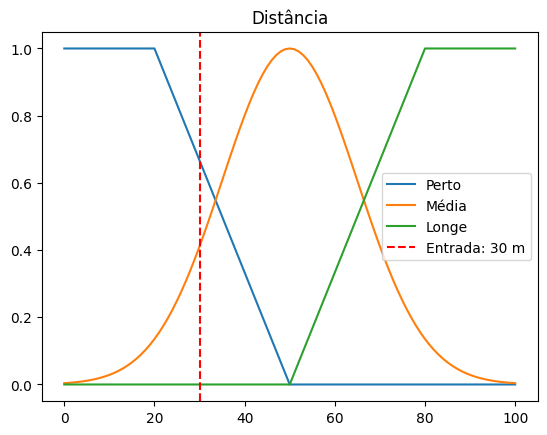

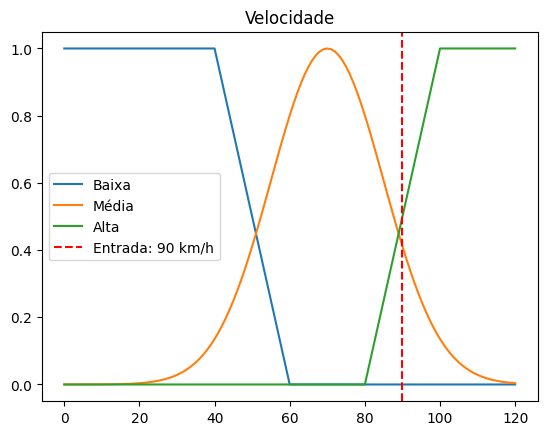

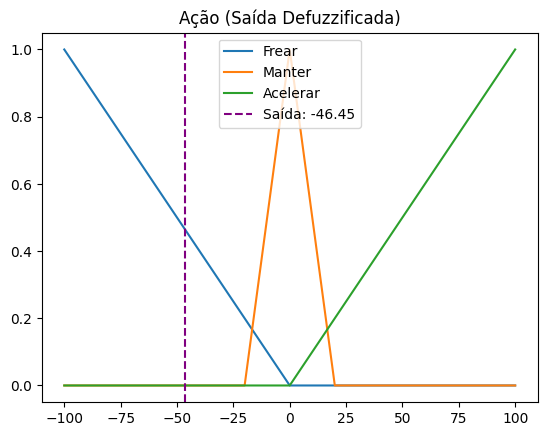

In [25]:
# -------- DISTÂNCIA --------
x_dist = distancia.universe

plt.figure()
# Alterado: Trapézio (trapmf) nas pontas e Gaussiana (gaussmf) no meio
plt.plot(x_dist, fuzz.trapmf(x_dist, [0, 0, 20, 50]), label='Perto')
plt.plot(x_dist, fuzz.gaussmf(x_dist, 50, 15), label='Média')
plt.plot(x_dist, fuzz.trapmf(x_dist, [50, 80, 100, 100]), label='Longe')

plt.axvline(dist_val, color='red', linestyle='--', label=f'Entrada: {dist_val} m')
plt.title('Distância')
plt.legend()
plt.show()


# -------- VELOCIDADE --------
x_vel = velocidade.universe

plt.figure()
# Alterado: Trapézio (trapmf) nas pontas e Gaussiana (gaussmf) no meio
plt.plot(x_vel, fuzz.trapmf(x_vel, [0, 0, 40, 60]), label='Baixa')
plt.plot(x_vel, fuzz.gaussmf(x_vel, 70, 15), label='Média')
plt.plot(x_vel, fuzz.trapmf(x_vel, [80, 100, 120, 120]), label='Alta')

plt.axvline(vel_val, color='red', linestyle='--', label=f'Entrada: {vel_val} km/h')
plt.title('Velocidade')
plt.legend()
plt.show()


# -------- AÇÃO --------
x_acao = acao.universe

plt.figure()
# Mantido: Triângulos (trimf) para manter o cálculo do Centróide justo e equilibrado
plt.plot(x_acao, fuzz.trimf(x_acao, [-100, -100, 0]), label='Frear')
plt.plot(x_acao, fuzz.trimf(x_acao, [-20, 0, 20]), label='Manter')
plt.plot(x_acao, fuzz.trimf(x_acao, [0, 100, 100]), label='Acelerar')

plt.axvline(acao_val, color='purple', linestyle='--', label=f'Saída: {acao_val:.2f}')
plt.title('Ação (Saída Defuzzificada)')
plt.legend()
plt.show()

Testando a ferramenta do skfuzzy pra fazer a mesma coisa:

c:\Users\jeanl\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


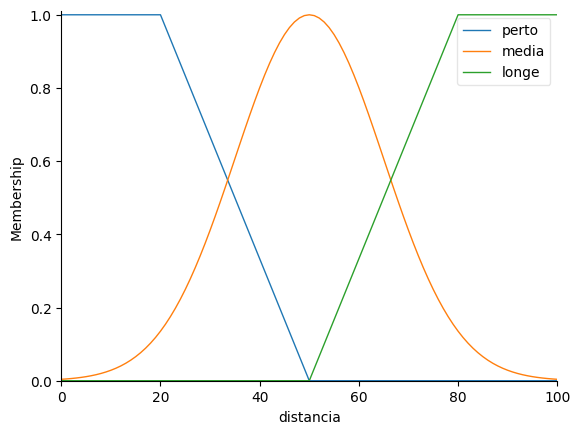

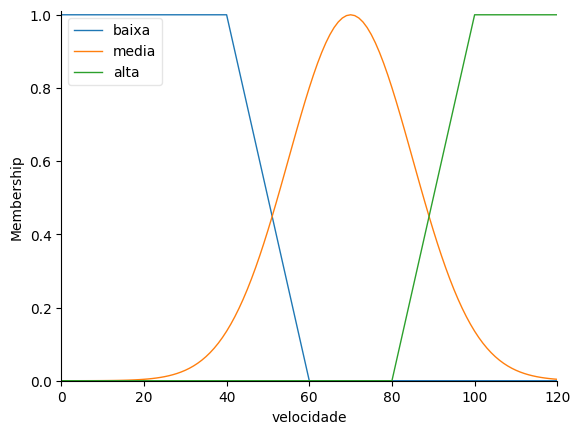

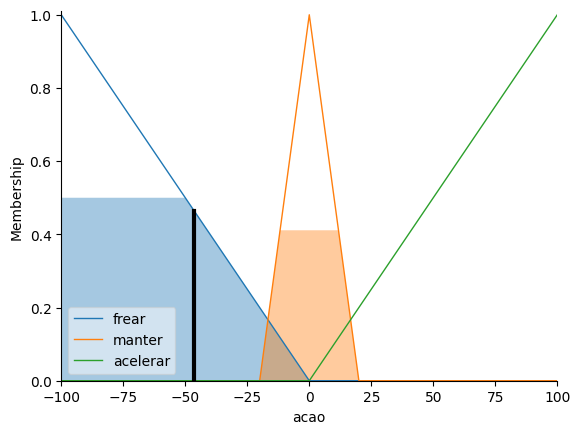

In [26]:
distancia.view()
velocidade.view()
acao.view(sim=simulador) # Este ainda desenha a área preenchida do centróide!

Calculando os graus de pertinencia do teste realizado:

In [24]:
# Valores de entrada
dist_val = 30
vel_val = 90

# -------- DISTÂNCIA --------
mu_perto = fuzz.interp_membership(distancia.universe,
                                  distancia['perto'].mf,
                                  dist_val)

mu_media = fuzz.interp_membership(distancia.universe,
                                  distancia['media'].mf,
                                  dist_val)

mu_longe = fuzz.interp_membership(distancia.universe,
                                  distancia['longe'].mf,
                                  dist_val)

# -------- VELOCIDADE --------
mu_baixa = fuzz.interp_membership(velocidade.universe,
                                  velocidade['baixa'].mf,
                                  vel_val)

mu_media_v = fuzz.interp_membership(velocidade.universe,
                                    velocidade['media'].mf,
                                    vel_val)

mu_alta = fuzz.interp_membership(velocidade.universe,
                                 velocidade['alta'].mf,
                                 vel_val)

# Print
print("Distância:")
print(f"Perto: {mu_perto:.2f}")
print(f"Média: {mu_media:.2f}")
print(f"Longe: {mu_longe:.2f}")

print("\nVelocidade:")
print(f"Baixa: {mu_baixa:.2f}")
print(f"Média: {mu_media_v:.2f}")
print(f"Alta: {mu_alta:.2f}")

Distância:
Perto: 0.67
Média: 0.41
Longe: 0.00

Velocidade:
Baixa: 0.00
Média: 0.41
Alta: 0.50
